In [2]:
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from hurst import compute_Hc
from arch.unitroot import VarianceRatio
from sklearn.linear_model import LinearRegression

ROUND_NUM = 5
BASE = 'round5'
DAYS = ['2', '3', '4']
colors = ['TRANSLATOR_SPACE_GRAY', 'TRANSLATOR_ASTRO_BLACK', 'TRANSLATOR_ECLIPSE_CHARCOAL', 'TRANSLATOR_GRAPHITE_MIST', 'TRANSLATOR_VOID_BLUE']

price_rows = []
offset = 0
for day in DAYS:
    with open(f'./{BASE}/prices_round_{ROUND_NUM}_day_{day}.csv') as f:
        for row in csv.DictReader(f, delimiter=';'):
            mid = row['mid_price']
            if row['product'] not in colors or not mid or float(mid) == 0:
                continue
            row['timestamp'] = int(row['timestamp']) + offset
            price_rows.append(row)
    offset += 1_000_000

prices = pd.DataFrame(price_rows)
for col in ['timestamp', 'bid_price_1', 'bid_volume_1', 'ask_price_1', 'ask_volume_1', 'mid_price']:
    prices[col] = pd.to_numeric(prices[col], errors='coerce')

del price_rows
del offset
del col
del day
del f
del row
del mid
prices.head()

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,2,0,TRANSLATOR_GRAPHITE_MIST,9996,15,9995,17,,,10004,15,10005,17,,,10000.0,0.0
1,2,0,TRANSLATOR_VOID_BLUE,9996,15,9995,17,,,10004,15,10005,17,,,10000.0,0.0
2,2,0,TRANSLATOR_SPACE_GRAY,9996,15,9995,17,,,10004,15,10005,17,,,10000.0,0.0
3,2,0,TRANSLATOR_ECLIPSE_CHARCOAL,9996,15,9995,17,,,10004,15,10005,17,,,10000.0,0.0
4,2,0,TRANSLATOR_ASTRO_BLACK,9996,15,9995,17,,,10004,15,10005,17,,,10000.0,0.0


In [3]:
GRAY, BLACK, CHARCOAL, MIST, BLUE = colors

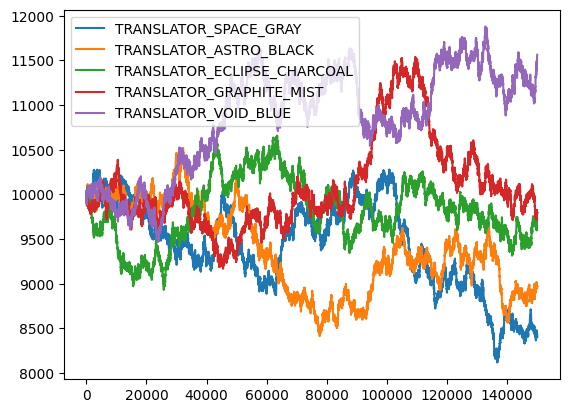

In [4]:
for p in colors:
    plt.plot(prices[prices['product'] == p]['mid_price'], label=p)
plt.legend()
plt.show()

In [5]:
mids = prices.pivot_table(
    index="timestamp",
    columns="product",
    values="mid_price",
).sort_index()

#mids["XL_XS_avg"] = (mids["PEBBLES_XL"] + mids["PEBBLES_XS"]) / 2
#mids["S_L_avg"]   = (mids["PEBBLES_S"]  + mids["PEBBLES_L"])  / 2

In [6]:
#plt.plot(mids["XL_XS_avg"], label="XL_XS")
#plt.plot(mids["S_L_avg"], label="S_L")
#plt.legend()

<Axes: title={'center': 'Average mid across all TRANSLATORS'}, xlabel='timestamp'>

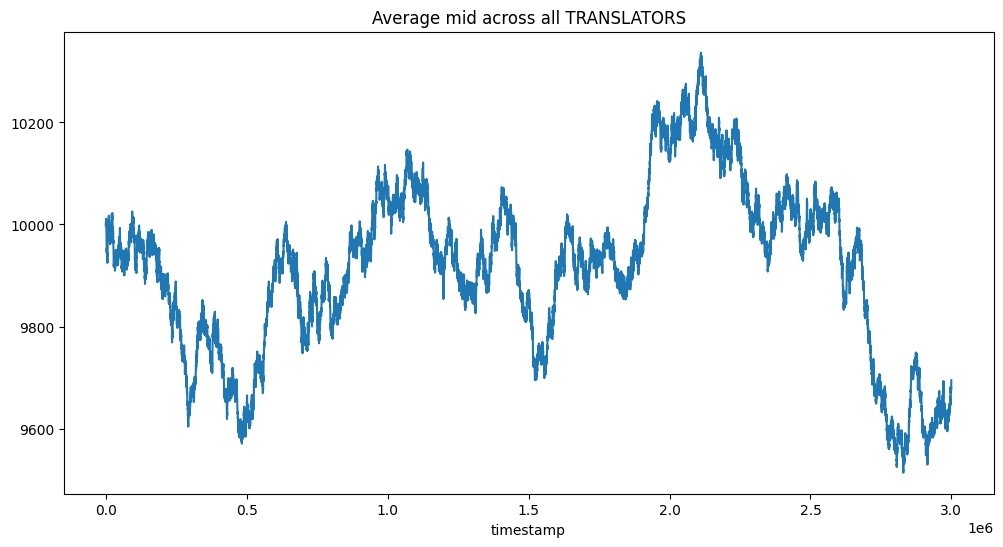

In [7]:
mids["TRANSLATORS_avg"] = mids[colors].mean(axis=1)
mids["TRANSLATORS_avg"].plot(figsize=(12, 6), title="Average mid across all TRANSLATORS")

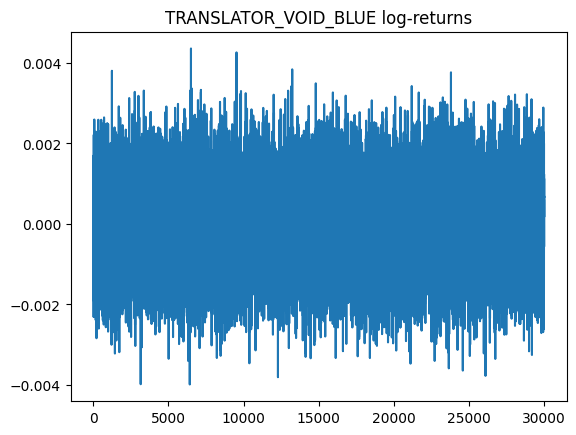

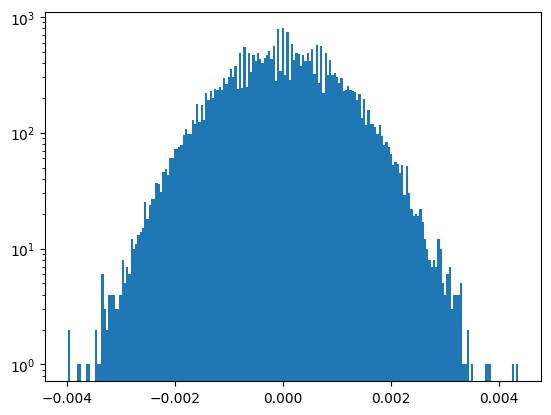

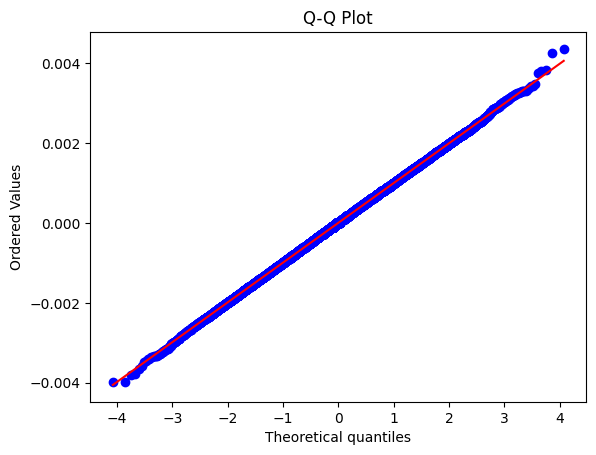

In [8]:
for s in colors[4:5]:
    log_ret = np.diff(np.log(mids[s]))
    plt.plot(log_ret)
    plt.title(f'{s} log-returns')
    plt.show()
    # Also look at the distribution
    plt.hist(log_ret, bins=200)
    plt.yscale('log')  # log scale to see tail behavior
    plt.show()
    stats.probplot(log_ret, dist="norm", plot=plt)
    plt.title('Q-Q Plot')

In [9]:
def estimate_gbm_params(prices, dt=1.0):
    """
    prices: price level series
    dt: time step size (1.0 if returns are already per-tick)
    """
    log_ret = np.diff(np.log(prices))
    n = len(log_ret)
    
    # MLE estimates
    mu_ret = np.mean(log_ret)       # mean log-return per tick
    sigma2 = np.var(log_ret, ddof=1) # variance of log-returns
    sigma = np.sqrt(sigma2 / dt)     # volatility per unit time
    
    # Drift of the price process (Ito correction)
    mu = mu_ret / dt + 0.5 * sigma2 / dt  # drift of S, not log(S)
    
    # Standard errors
    se_mu_ret = np.sqrt(sigma2 / n)
    se_sigma = sigma / np.sqrt(2 * (n-1))
    
    # t-stat for drift being nonzero
    t_stat = mu_ret / se_mu_ret
    
    return {
        'mu_log': mu_ret,        # mean log-return per tick
        'mu': mu,                # drift of price process
        'sigma': sigma,          # volatility
        'se_mu': se_mu_ret,      # std error of mean log-return
        'se_sigma': se_sigma,    # std error of sigma
        't_stat_drift': t_stat,  # is drift significantly nonzero?
    }

for asset in colors:
    params = estimate_gbm_params(mids[asset])
    print(f"{asset}: mu_log={params['mu_log']:.6f} "
          f"(t={params['t_stat_drift']:.2f}) "
          f"sigma={params['sigma']:.6f}")

TRANSLATOR_SPACE_GRAY: mu_log=-0.000006 (t=-0.99) sigma=0.000998
TRANSLATOR_ASTRO_BLACK: mu_log=-0.000004 (t=-0.63) sigma=0.001004
TRANSLATOR_ECLIPSE_CHARCOAL: mu_log=-0.000001 (t=-0.16) sigma=0.001004
TRANSLATOR_GRAPHITE_MIST: mu_log=-0.000001 (t=-0.12) sigma=0.001003
TRANSLATOR_VOID_BLUE: mu_log=0.000005 (t=0.84) sigma=0.000996


# As suspected...
All of these are GBMs, none of them have significant drift --> have to do cointegration or something

In [10]:
from statsmodels.tsa.stattools import coint
import itertools

for a1, a2 in itertools.combinations(colors, 2):
    pval = coint(mids[a1], mids[a2])[1]
    print(f"{a1} vs {a2}: p={pval:.4f}")
    # p < 0.05 means cointegrated → pairs trade

TRANSLATOR_SPACE_GRAY vs TRANSLATOR_ASTRO_BLACK: p=0.8179
TRANSLATOR_SPACE_GRAY vs TRANSLATOR_ECLIPSE_CHARCOAL: p=0.8353
TRANSLATOR_SPACE_GRAY vs TRANSLATOR_GRAPHITE_MIST: p=0.8416
TRANSLATOR_SPACE_GRAY vs TRANSLATOR_VOID_BLUE: p=0.6116
TRANSLATOR_ASTRO_BLACK vs TRANSLATOR_ECLIPSE_CHARCOAL: p=0.5799
TRANSLATOR_ASTRO_BLACK vs TRANSLATOR_GRAPHITE_MIST: p=0.6210
TRANSLATOR_ASTRO_BLACK vs TRANSLATOR_VOID_BLUE: p=0.2064
TRANSLATOR_ECLIPSE_CHARCOAL vs TRANSLATOR_GRAPHITE_MIST: p=0.3137
TRANSLATOR_ECLIPSE_CHARCOAL vs TRANSLATOR_VOID_BLUE: p=0.1249
TRANSLATOR_GRAPHITE_MIST vs TRANSLATOR_VOID_BLUE: p=0.6777


In [ ]:
from itertools import combinations
from statsmodels.tsa.vector_ar.vecm import coint_johansen

assets = colors
results = []
for r in [2, 3, 4, 5]:
    for combo in combinations(assets, r):
        price_matrix = np.column_stack([mids[a] for a in combo])
        
        # Train/test split
        train = price_matrix[:20000]
        test = price_matrix[20000:]
        
        joh = coint_johansen(train, det_order=0, k_ar_diff=1)
        
        n_significant = sum(
            joh.lr1[i] > joh.cvt[i, 1]  # 95% critical value
            for i in range(len(joh.eig))
        )
        
        if n_significant > 0:
            # Validate on test set
            beta = joh.evec[:, 0]
            spread_test = test @ beta
            adf_pval = adfuller(spread_test)[1]
            
            results.append({
                'assets': combo,
                'n_vectors': n_significant,
                'eigenvalue': joh.eig[0],
                'oos_adf': adf_pval
            })
            print(f"{combo}: vectors={n_significant}, "
                  f"eigenvalue={joh.eig[0]:.6f}, "
                  f"OOS ADF={adf_pval:.4f}")

# Sort by out-of-sample ADF p-value
results.sort(key=lambda x: x['oos_adf'])
print("\nBest combinations:")
for r in results[:5]:
    print(r)

('TRANSLATOR_SPACE_GRAY', 'TRANSLATOR_ECLIPSE_CHARCOAL'): vectors=1, eigenvalue=0.000671, OOS ADF=0.4988

Best combinations:
{'assets': ('TRANSLATOR_SPACE_GRAY', 'TRANSLATOR_ECLIPSE_CHARCOAL'), 'n_vectors': np.int64(1), 'eigenvalue': np.float64(0.0006707580640797298), 'oos_adf': np.float64(0.49875597996220894)}


In [18]:
# 1. Check if any asset has significant drift
# (you said insignificant but just confirm t > 2 threshold)

# 2. Check PCA - if first PC explains >> 20% there's a common factor
from sklearn.decomposition import PCA
log_rets = np.column_stack([np.diff(np.log(mids[a])) for a in assets])
pca = PCA()
pca.fit(log_rets)
print(pca.explained_variance_ratio_)
# For 5 independent GBMs expect each ~20%
# If first PC is say 60%+ there's a hidden common factor

[0.20372359 0.20299272 0.2010257  0.19753041 0.19472759]


# I have no fucking idea
Cointegration didn't find anything significant and neither did PCA. I think this might be a little cooked or maybe this is where the lag factor might come in. Maybe we could try cointegration with lagged time series but idk